# Bifiltration Persistent Homology — Fire Station Coverage × Heat Vulnerability
## Finding communities simultaneously far from first responders and heat-vulnerable


This notebook implements a genuine **bifiltration** `F(ε, h)`, where:
- `ε` = Rips filtration radius (metres) — captures geographic isolation from fire stations
- `h` = HVI sublevel threshold — captures heat vulnerability

A simplex enters the bifiltration at a **pair** `(ε, h)`, not a single value.
We analyze structure across the entire 2D parameter space rather than along one axis.

### The slice approach

Full 2-parameter persistent homology is computationally intractable for large clouds.
We use the **RIVET-style diagonal slice method**: for each line
`L: h = m·ε + b` through the parameter plane, restrict the bifiltration to L and
compute standard 1D persistence. Different slope/intercept combinations emphasize
different tradeoffs between spatial and vulnerability dimensions.

| Slice angle | What it emphasizes |
|---|---|
| Steep slope (m large) | HVI gap dominates — finds vulnerability hotspots |
| Shallow slope (m small) | Geographic gap dominates — finds spatially isolated areas |
| Balanced slope | Both gaps matter equally — true dual-risk zones |

Neighborhoods that show **persistent H1 voids across multiple slice angles** are the
true high-risk zones — not just geographically underserved, not just vulnerable,
but both simultaneously and robustly.

### Pipeline
1. Imports & configuration
2. Load all datasets
3. Assign HVI to neighborhoods + compute station distances
4. Build the bifiltration: assign `(ε_entry, h_entry)` to every simplex
5. Diagonal slice persistence — sweep across multiple slice lines
6. Persistence diagrams and barcodes per slice
7. Project H1 voids back to 2D geographic map
8. Neighborhood risk table with bifiltration gap score

## Step 0 — Install dependencies (run once)

In [1]:
# Uncomment and run if packages are not yet installed
# !pip install gudhi geopandas shapely pyproj --quiet

## Step 1 — Imports & Configuration

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import gudhi
from shapely.ops import unary_union
from scipy.spatial.distance import cdist, pdist, squareform
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# ── Paths ──────────────────────────────────────────────────────────────────
STATIONS_PATH  = "../../data/all_stations.geojson"
LA_COUNTY_PATH = "../../data/la_county.geojson"
HVI_PATH       = "../../data/HVI_LACounty.csv"

CRS_WGS84 = "EPSG:4326"
CRS_UTM   = "EPSG:32611"   # UTM Zone 11N — metres

# ── Bifiltration configuration ─────────────────────────────────────────────
# Geographic axis: Rips filtration radius ceiling (metres)
RIPS_MAX_M = 20_000          # 20 km — covers inter-station gaps at county scale

# HVI axis: sublevel threshold range
# HVI typically ranges 1–100; we sweep the full observed range
HVI_MIN    = 0
HVI_MAX    = 100

# ── Slice configuration ────────────────────────────────────────────────────
# Each slice line is: h = m * (ε / RIPS_MAX_M) + b
# ε is normalised to [0,1] so m and b are in HVI units
#
# We define slices by (slope_label, m, b) to cover:
#   - geography-first  (m small, b low)  → finds spatially isolated zones
#   - balanced         (m ≈ 1 in HVI)    → finds dual-risk zones
#   - vulnerability-first (m large)      → finds HVI-dominant risk zones
SLICES = [
    ("geography-first",    10,   5),   # h = 10*(ε/max) + 5
    ("balanced-low",       30,  10),   # h = 30*(ε/max) + 10
    ("balanced",           50,  15),   # h = 50*(ε/max) + 15
    ("balanced-high",      70,  20),   # h = 70*(ε/max) + 20
    ("vulnerability-first",90,  25),   # h = 90*(ε/max) + 25
]

# ── Significance threshold ─────────────────────────────────────────────────
# H1 pairs with persistence below this are noise; above = meaningful void
H1_THRESH_M = 1_500          # 1.5 km in Rips-slice space

# ── Dual-risk definition ───────────────────────────────────────────────────
# A neighborhood is "dual-risk" if it lies inside a significant H1 void
# in at least this many slice angles
DUAL_RISK_MIN_SLICES = 3     # out of 5 slices

# ── Evaluation radius for Betti table ─────────────────────────────────────
EVAL_RADII_M = [2000, 4000, 6000, 8000, 10000, 15000, 20000]

print("Configuration loaded.")
print(f"  Rips ceiling  : {RIPS_MAX_M/1000:.0f} km")
print(f"  HVI range     : {HVI_MIN} – {HVI_MAX}")
print(f"  Slice lines   : {len(SLICES)}")
print(f"  H1 threshold  : {H1_THRESH_M/1000:.1f} km")

Configuration loaded.
  Rips ceiling  : 20 km
  HVI range     : 0 – 100
  Slice lines   : 5
  H1 threshold  : 1.5 km


## Step 2 — Load All Datasets

In [3]:
la_county = gpd.read_file(LA_COUNTY_PATH).set_crs(CRS_WGS84, allow_override=True)
stations  = gpd.read_file(STATIONS_PATH).set_crs(CRS_WGS84, allow_override=True)
hvi_df    = pd.read_csv(HVI_PATH)

print(f"Neighborhoods  : {len(la_county)}")
print(f"Fire stations  : {len(stations)}")
print(f"HVI tracts     : {len(hvi_df)}  (null HVI: {hvi_df['hvi'].isna().sum()})")
print(f"HVI range      : {hvi_df['hvi'].min():.1f} – {hvi_df['hvi'].max():.1f}")
hvi_df.head(3)

Neighborhoods  : 272
Fire stations  : 412
HVI tracts     : 2344  (null HVI: 19)
HVI range      : 5.4 – 90.8


,census_tract,census_county,census_city,hvi
0,6037101110,Los Angeles County,Tujunga,36.53
1,6037101122,Los Angeles County,Tujunga,19.76
2,6037101210,Los Angeles County,Tujunga,43.45


## Step 3 — Assign HVI to Neighborhoods & Compute Station Distances

Each neighborhood centroid gets:
- `hvi_median` — aggregated HVI score (name-match, fallback to county median)
- `min_dist_m` — Euclidean distance to nearest fire station (UTM metres)

These two values are the axes of our bifiltration.

In [4]:
# ── Clip & project stations ────────────────────────────────────────────────
county_boundary = unary_union(la_county.geometry)
stations_clip   = stations[stations.geometry.within(county_boundary)].copy()
stations_proj   = stations_clip.to_crs(CRS_UTM).reset_index(drop=True)
county_proj     = la_county.to_crs(CRS_UTM)

coords_stations = np.column_stack([stations_proj.geometry.x,
                                    stations_proj.geometry.y])
print(f"Stations after clip+project: {len(coords_stations)}")

# ── Assign HVI by neighborhood name ───────────────────────────────────────
hvi_clean   = hvi_df.dropna(subset=["hvi"]).copy()
county_med  = hvi_clean["hvi"].median()

hvi_by_city = (
    hvi_clean.groupby("census_city")["hvi"]
    .median()
    .reset_index()
    .rename(columns={"census_city": "name", "hvi": "hvi_median"})
)

county_proj = county_proj.merge(hvi_by_city, on="name", how="left")
county_proj["hvi_median"] = county_proj["hvi_median"].fillna(county_med)

matched = (county_proj["hvi_median"] != county_med).sum()
print(f"HVI direct match  : {matched} neighborhoods")
print(f"Filled with median: {len(county_proj) - matched} neighborhoods")
print(f"County median HVI : {county_med:.2f}")

# ── Per-neighborhood centroid coordinates ──────────────────────────────────
county_proj["cx"] = county_proj.geometry.centroid.x
county_proj["cy"] = county_proj.geometry.centroid.y
hood_centroids = county_proj[["cx", "cy"]].values

# ── Min distance to nearest station per neighborhood ───────────────────────
# Chunked to avoid memory issues on large county grids
def min_dist_chunked(query_pts, ref_pts, chunk=300):
    d = np.full(len(query_pts), np.inf)
    for s in range(0, len(query_pts), chunk):
        e = min(s + chunk, len(query_pts))
        d[s:e] = cdist(query_pts[s:e], ref_pts).min(axis=1)
    return d

county_proj["min_dist_m"] = min_dist_chunked(hood_centroids, coords_stations)

print(f"\nDistance to nearest station (km):")
print(f"  Min   : {county_proj['min_dist_m'].min()/1000:.2f}")
print(f"  Median: {county_proj['min_dist_m'].median()/1000:.2f}")
print(f"  Max   : {county_proj['min_dist_m'].max()/1000:.2f}")
print(f"\nHVI distribution:")
print(county_proj["hvi_median"].describe().round(2))

Stations after clip+project: 408
HVI direct match  : 109 neighborhoods
Filled with median: 163 neighborhoods
County median HVI : 42.72

Distance to nearest station (km):
  Min   : 0.09
  Median: 1.19
  Max   : 42.79

HVI distribution:
count    272.00
mean      39.92
std        8.46
min       11.54
25%       40.84
50%       42.72
75%       42.72
max       60.51
Name: hvi_median, dtype: float64


## Step 4 — Build the Bifiltration

### What is a bifiltration?

A standard filtration is a nested sequence of simplicial complexes indexed by one
parameter `ε`: `K(ε₁) ⊆ K(ε₂)` whenever `ε₁ ≤ ε₂`.

A **bifiltration** `F(ε, h)` is a doubly-nested sequence indexed by two parameters:
`F(ε₁, h₁) ⊆ F(ε₂, h₂)` whenever `ε₁ ≤ ε₂` **and** `h₁ ≤ h₂`.

### Our construction

Points are neighborhood centroids. Each centroid `i` enters the bifiltration at:
- `ε_entry(i) = 0`  (all points are present from the start geographically)
- `h_entry(i) = hvi_median(i)`  (a point is "active" once the HVI threshold reaches it)

An edge `(i, j)` enters at:
- `ε_entry(i,j) = dist(i, j)` — the Euclidean distance between centroids
- `h_entry(i,j) = max(hvi(i), hvi(j))` — both endpoints must be HVI-active

A triangle `(i, j, k)` enters at:
- `ε_entry = max of the three edge distances` (Rips rule)
- `h_entry = max of the three vertex HVI values`

This means a high-HVI gap between two neighborhoods only appears in the filtration
once the HVI threshold is high enough — it cannot be "closed" by a low-HVI route.

In [5]:
def build_bifiltration(hood_centroids, hvi_values, rips_max_m):
    """
    Build bifiltration entry values (eps_entry, hvi_entry) for all simplices
    up to dimension 2 (vertices, edges, triangles).

    Parameters
    ----------
    hood_centroids : (N, 2) UTM coordinates of neighborhood centroids
    hvi_values     : (N,)  HVI score per neighborhood
    rips_max_m     : scalar  maximum edge length (metres)

    Returns
    -------
    simplices : list of tuples (simplex_tuple, eps_entry, hvi_entry)
    D         : (N, N) pairwise distance matrix (for reuse in later steps)
    """
    N = len(hood_centroids)
    D = squareform(pdist(hood_centroids))
    simplices = []

    # 0-simplices (vertices)
    for i in range(N):
        simplices.append(((i,), 0.0, hvi_values[i]))

    # 1-simplices (edges within rips_max_m)
    for i in range(N):
        for j in range(i + 1, N):
            d = D[i, j]
            if d <= rips_max_m:
                simplices.append(
                    ((i, j),
                     d,                                    # ε_entry
                     max(hvi_values[i], hvi_values[j]))    # h_entry
                )

    # 2-simplices (triangles — all three edges must be within rips_max_m)
    for i in range(N):
        for j in range(i + 1, N):
            if D[i, j] > rips_max_m:
                continue
            for k in range(j + 1, N):
                if D[i, k] > rips_max_m or D[j, k] > rips_max_m:
                    continue
                simplices.append(
                    ((i, j, k),
                     max(D[i,j], D[i,k], D[j,k]),
                     max(hvi_values[i], hvi_values[j], hvi_values[k]))
                )

    return simplices, D


hvi_values  = county_proj["hvi_median"].values
N_hoods     = len(hood_centroids)

print(f"Building bifiltration on {N_hoods} neighborhood centroids ...")
print(f"  Rips ceiling: {RIPS_MAX_M/1000:.0f} km")

simplices, D_hoods = build_bifiltration(hood_centroids, hvi_values, RIPS_MAX_M)

n_verts = sum(1 for s, _, _ in simplices if len(s) == 1)
n_edges = sum(1 for s, _, _ in simplices if len(s) == 2)
n_tris  = sum(1 for s, _, _ in simplices if len(s) == 3)

print(f"\nBifiltration built:")
print(f"  Vertices  : {n_verts}")
print(f"  Edges     : {n_edges:,}")
print(f"  Triangles : {n_tris:,}")
print(f"  Total     : {len(simplices):,} simplices")

Building bifiltration on 272 neighborhood centroids ...
  Rips ceiling: 20 km

Bifiltration built:
  Vertices  : 272
  Edges     : 10,023
  Triangles : 227,614
  Total     : 237,909 simplices


## Step 5 — Diagonal Slice Persistent Homology

### The slice method

For each slice line `L: h = m·ε̂ + b` (where `ε̂ = ε / RIPS_MAX_M` normalises
ε to [0,1] so m and b are in HVI units), we:

1. Map each 2D bifiltration entry `(ε_entry, h_entry)` to a 1D position
   along L using the projection `t = max(ε̂, (h - b) / m)`
   — this is the earliest point on L where **both** conditions are satisfied
2. Build a standard GUDHI simplex tree with these 1D entries
3. Compute standard persistence

The projection formula `t = max(ε̂, (h - b) / m)` ensures monotonicity:
a simplex can only enter L when *both* the geographic parameter and
the HVI parameter have been reached. This is the correct restriction
of the bifiltration to the slice line.

In [6]:
def slice_to_1d(simplices, m, b, rips_max_m):
    """
    Project bifiltration entries onto the slice line L: h = m*eps_norm + b.

    For each simplex with (eps_entry, hvi_entry), compute the 1D parameter t
    at which the simplex enters the restriction of the bifiltration to L.

    t = max(eps_norm, (hvi_entry - b) / m)  if m > 0
    t = eps_norm  if m == 0 and hvi_entry <= b  (HVI already satisfied)
    t = inf       if m == 0 and hvi_entry > b   (HVI never satisfied)

    The 1D entry is then t * rips_max_m (back to metres for persistence).

    Returns
    -------
    entries : list of (simplex_tuple, t_metres)
    """
    entries = []
    for simp_tuple, eps_entry, hvi_entry in simplices:
        eps_norm = eps_entry / rips_max_m
        if m > 0:
            t_hvi = (hvi_entry - b) / m
        else:
            t_hvi = 0.0 if hvi_entry <= b else np.inf
        t_norm = max(eps_norm, t_hvi)
        if np.isinf(t_norm):
            continue   # simplex never enters this slice — skip
        entries.append((simp_tuple, t_norm * rips_max_m))
    return entries


def compute_slice_ph(simplices, m, b, rips_max_m, label):
    """
    Build a GUDHI simplex tree from the slice projection and compute persistence.

    Returns
    -------
    diag : dict with keys H0, H0_inf, H1, H1_inf
    st   : the GUDHI simplex tree (for Betti queries)
    """
    entries = slice_to_1d(simplices, m, b, rips_max_m)

    st = gudhi.SimplexTree()
    for simp_tuple, t in entries:
        st.insert(list(simp_tuple), filtration=t)
    st.make_filtration_non_decreasing()
    st.compute_persistence(homology_coeff_field=2, min_persistence=0)

    H0, H0_inf, H1, H1_inf = [], [], [], []
    for dim, (b_, d_) in st.persistence():
        if   dim == 0: (H0_inf if np.isinf(d_) else H0).append((b_, d_))
        elif dim == 1: (H1_inf if np.isinf(d_) else H1).append((b_, d_))

    print(f"  [{label}]  H0={len(H0)+len(H0_inf)}  H1={len(H1)+len(H1_inf)}  "
          f"(significant H1: {sum(1 for b_,d_ in H1 if d_-b_ >= H1_THRESH_M)})")

    return {"H0": H0, "H0_inf": H0_inf, "H1": H1, "H1_inf": H1_inf}, st


print("Computing slice PH for each slice angle ...\n")
slice_results = {}   # label -> (diag, simplex_tree, m, b)

for label, m, b in SLICES:
    diag, st = compute_slice_ph(simplices, m, b, RIPS_MAX_M, label)
    slice_results[label] = (diag, st, m, b)

print("\nDone.")

Computing slice PH for each slice angle ...

  [geography-first]  H0=12  H1=4  (significant H1: 2)
  [balanced-low]  H0=23  H1=5  (significant H1: 1)
  [balanced]  H0=43  H1=9  (significant H1: 2)
  [balanced-high]  H0=69  H1=22  (significant H1: 6)
  [vulnerability-first]  H0=110  H1=60  (significant H1: 7)

Done.


## Step 6 — Persistence Diagrams & Barcodes per Slice

Each panel shows persistence for one slice angle.
H1 points far above the diagonal = long-lived voids = real coverage gaps at that
weighting of geographic vs vulnerability dimensions.

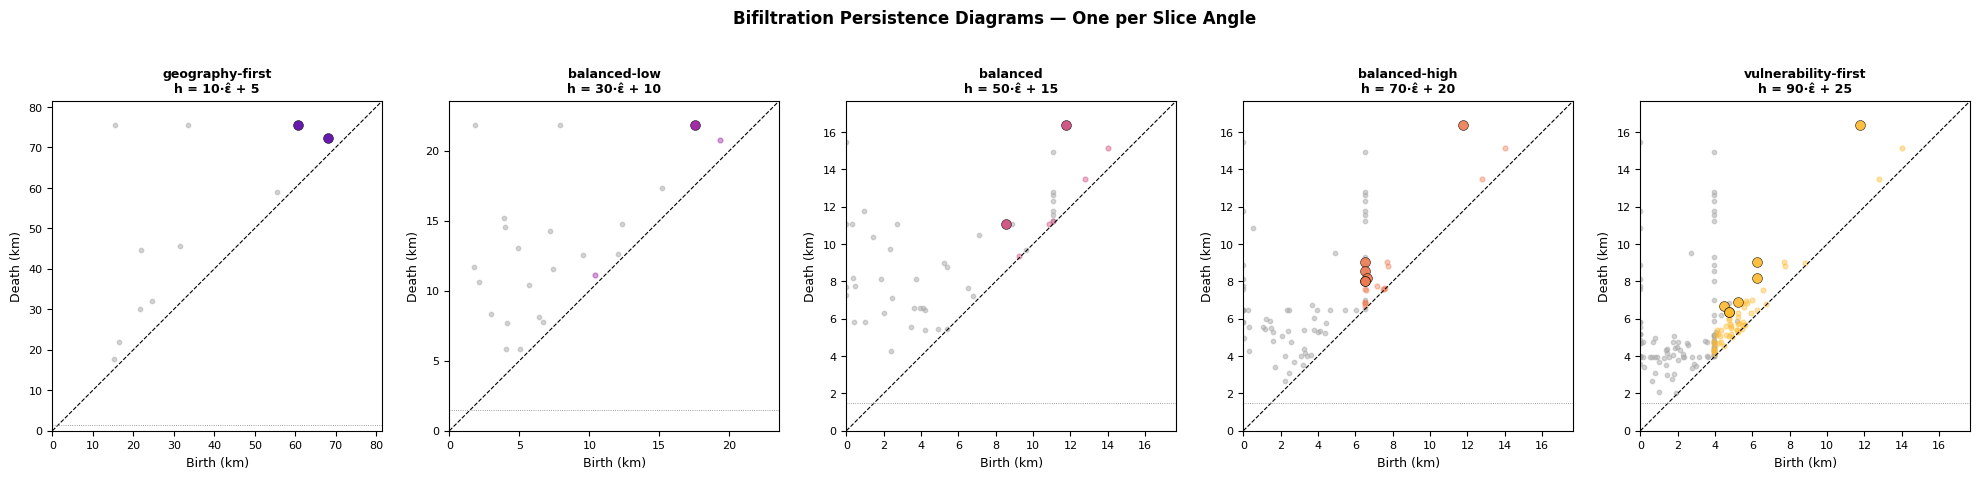

In [7]:
n_slices = len(SLICES)
fig, axes = plt.subplots(1, n_slices, figsize=(4 * n_slices, 5))

slice_colors = plt.cm.plasma(np.linspace(0.15, 0.85, n_slices))

for ax, (label, m, b), color in zip(axes, SLICES, slice_colors):
    diag = slice_results[label][0]

    all_finite = diag["H0"] + diag["H1"]
    if all_finite:
        lim = max(d for _, d in all_finite) / 1000 * 1.08
    else:
        lim = RIPS_MAX_M / 1000

    # H0 pairs
    if diag["H0"]:
        arr = np.array(diag["H0"])
        ax.scatter(arr[:,0]/1000, arr[:,1]/1000,
                   c="#aaa", s=10, alpha=0.5, label="H0")

    # H1 pairs — sized by persistence
    if diag["H1"]:
        arr = np.array(diag["H1"])
        pers = arr[:,1] - arr[:,0]
        sig  = pers >= H1_THRESH_M
        ax.scatter(arr[~sig,0]/1000, arr[~sig,1]/1000,
                   c=[color], s=12, alpha=0.4, label="H1 (noise)")
        ax.scatter(arr[sig,0]/1000, arr[sig,1]/1000,
                   c=[color], s=50, alpha=0.9, edgecolors="k",
                   linewidths=0.4, label="H1 (significant)")

    ax.plot([0, lim], [0, lim], "k--", lw=0.8)
    ax.axhline(H1_THRESH_M/1000, color="gray", lw=0.6, linestyle=":")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("Birth (km)", fontsize=9)
    ax.set_ylabel("Death (km)", fontsize=9)
    ax.set_title(f"{label}\nh = {m}·ε̂ + {b}", fontsize=9, fontweight="bold")
    ax.set_aspect("equal")
    ax.tick_params(labelsize=8)

plt.suptitle("Bifiltration Persistence Diagrams — One per Slice Angle",
             fontsize=12, fontweight="bold")
plt.tight_layout()
# plt.savefig("bifiltration_persistence_diagrams.png", dpi=150, bbox_inches="tight")
plt.show()
# print("Saved: bifiltration_persistence_diagrams.png")

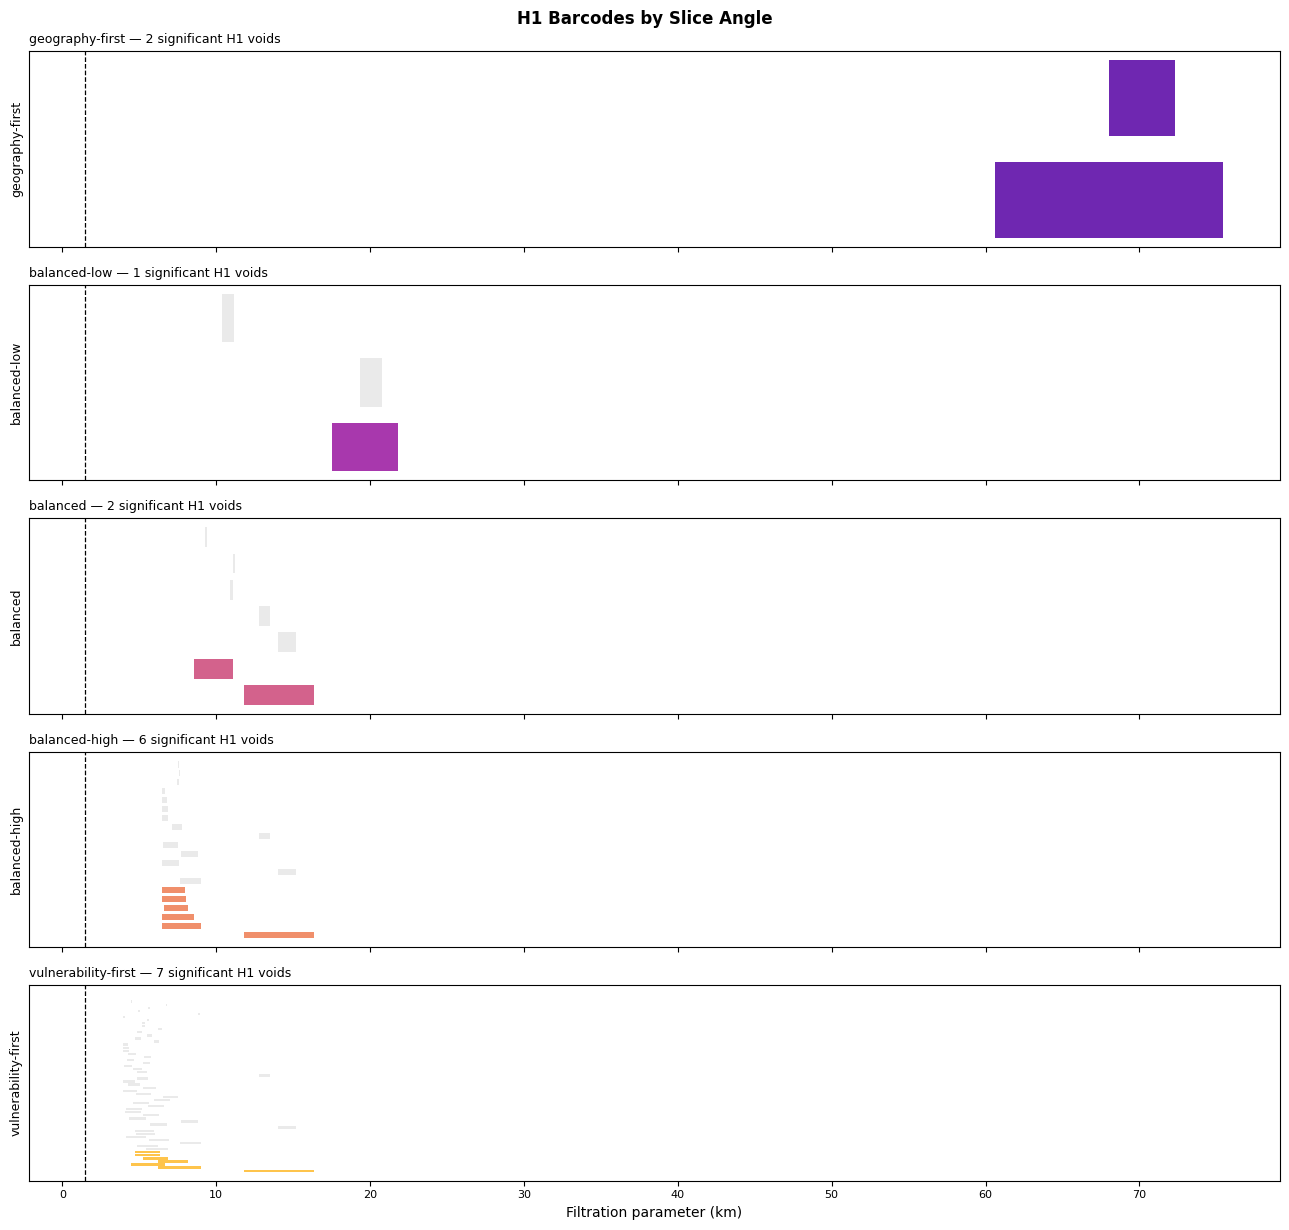

In [8]:
# ── Barcodes for all slices ────────────────────────────────────────────────
fig, axes = plt.subplots(n_slices, 1, figsize=(13, 2.5 * n_slices), sharex=True)

for ax, (label, m, b), color in zip(axes, SLICES, slice_colors):
    diag = slice_results[label][0]
    pairs = sorted(diag["H1"], key=lambda x: x[1] - x[0], reverse=True)

    for i, (birth, death) in enumerate(pairs):
        pers    = death - birth
        is_sig  = pers >= H1_THRESH_M
        ax.barh(i, (death - birth)/1000, left=birth/1000,
                color=color if is_sig else "#ccc",
                alpha=0.85 if is_sig else 0.4,
                height=0.75)

    ax.axvline(H1_THRESH_M/1000, color="black", linestyle="--",
               lw=0.9, label=f"threshold {H1_THRESH_M/1000:.1f} km")
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis="y", left=False, labelleft=False)
    ax.tick_params(labelsize=8)
    n_sig = sum(1 for b_,d_ in diag["H1"] if d_-b_ >= H1_THRESH_M)
    ax.set_title(f"{label} — {n_sig} significant H1 voids",
                 fontsize=9, loc="left")

axes[-1].set_xlabel("Filtration parameter (km)", fontsize=10)
plt.suptitle("H1 Barcodes by Slice Angle",
             fontsize=12, fontweight="bold")
plt.tight_layout()
# plt.savefig("bifiltration_barcodes.png", dpi=150, bbox_inches="tight")
plt.show()
# print("Saved: bifiltration_barcodes.png")

## Step 7 — Identify Dual-Risk Neighborhoods

A neighborhood is a **dual-risk zone** if it satisfies both conditions robustly:
- it lies inside a significant H1 void in the geographic dimension (far from stations)
- it lies inside a significant H1 void in the vulnerability dimension (high HVI)
- and this holds across **multiple slice angles**, not just one

The multi-slice criterion is the key advantage of bifiltration over single-parameter PH:
it filters out neighborhoods that are only risky along one dimension.

In [9]:
def voids_in_slice(diag, threshold_m):
    """Return significant H1 voids as (birth, death, persistence) triples."""
    return [
        (b, d, d - b)
        for b, d in diag["H1"]
        if d - b >= threshold_m
    ]


def neighborhood_in_void(min_dist_m, voids):
    """
    A neighborhood is 'inside' a void if its distance to the nearest station
    falls within the void's [birth, death] interval.

    Birth  = the radius at which the void opens   (far from coverage)
    Death  = the radius at which the void closes  (coverage finally reached)
    Inside = the neighborhood is in the gap between these two radii
    """
    for b, d, _ in voids:
        if b <= min_dist_m <= d:
            return True
    return False


# For each neighborhood, count in how many slices it falls inside a void
county_proj["n_slices_in_void"] = 0
county_proj["void_persistence_sum"] = 0.0

for label, m, b in SLICES:
    diag   = slice_results[label][0]
    voids  = voids_in_slice(diag, H1_THRESH_M)
    in_v   = county_proj["min_dist_m"].apply(lambda d: neighborhood_in_void(d, voids))
    county_proj["n_slices_in_void"] += in_v.astype(int)

    # Sum persistence of the void each neighborhood falls into
    def best_void_pers(d):
        matching = [(p) for b_, d_, p in voids if b_ <= d <= d_]
        return max(matching) if matching else 0.0
    county_proj["void_persistence_sum"] += county_proj["min_dist_m"].apply(best_void_pers)

county_proj["dual_risk"] = county_proj["n_slices_in_void"] >= DUAL_RISK_MIN_SLICES

print(f"Dual-risk neighborhoods (≥ {DUAL_RISK_MIN_SLICES} of {len(SLICES)} slices):")
print(f"  Total: {county_proj['dual_risk'].sum()} of {len(county_proj)} neighborhoods")
print()
print("Slice void membership:")
print(county_proj["n_slices_in_void"].value_counts().sort_index())

Dual-risk neighborhoods (≥ 3 of 5 slices):
  Total: 3 of 272 neighborhoods

Slice void membership:
n_slices_in_void
0    264
1      5
3      3
Name: count, dtype: int64


## Step 8 — Project H1 Voids to 2D Geographic Map

Visualise the dual-risk neighborhoods on a choropleth map.
- Base layer: HVI score per neighborhood (red = high vulnerability)
- Blue dots: fire station locations
- Hatched polygons: dual-risk neighborhoods — simultaneously geographically isolated AND heat-vulnerable
- Colour intensity: number of slice angles in which the neighborhood lies inside a void

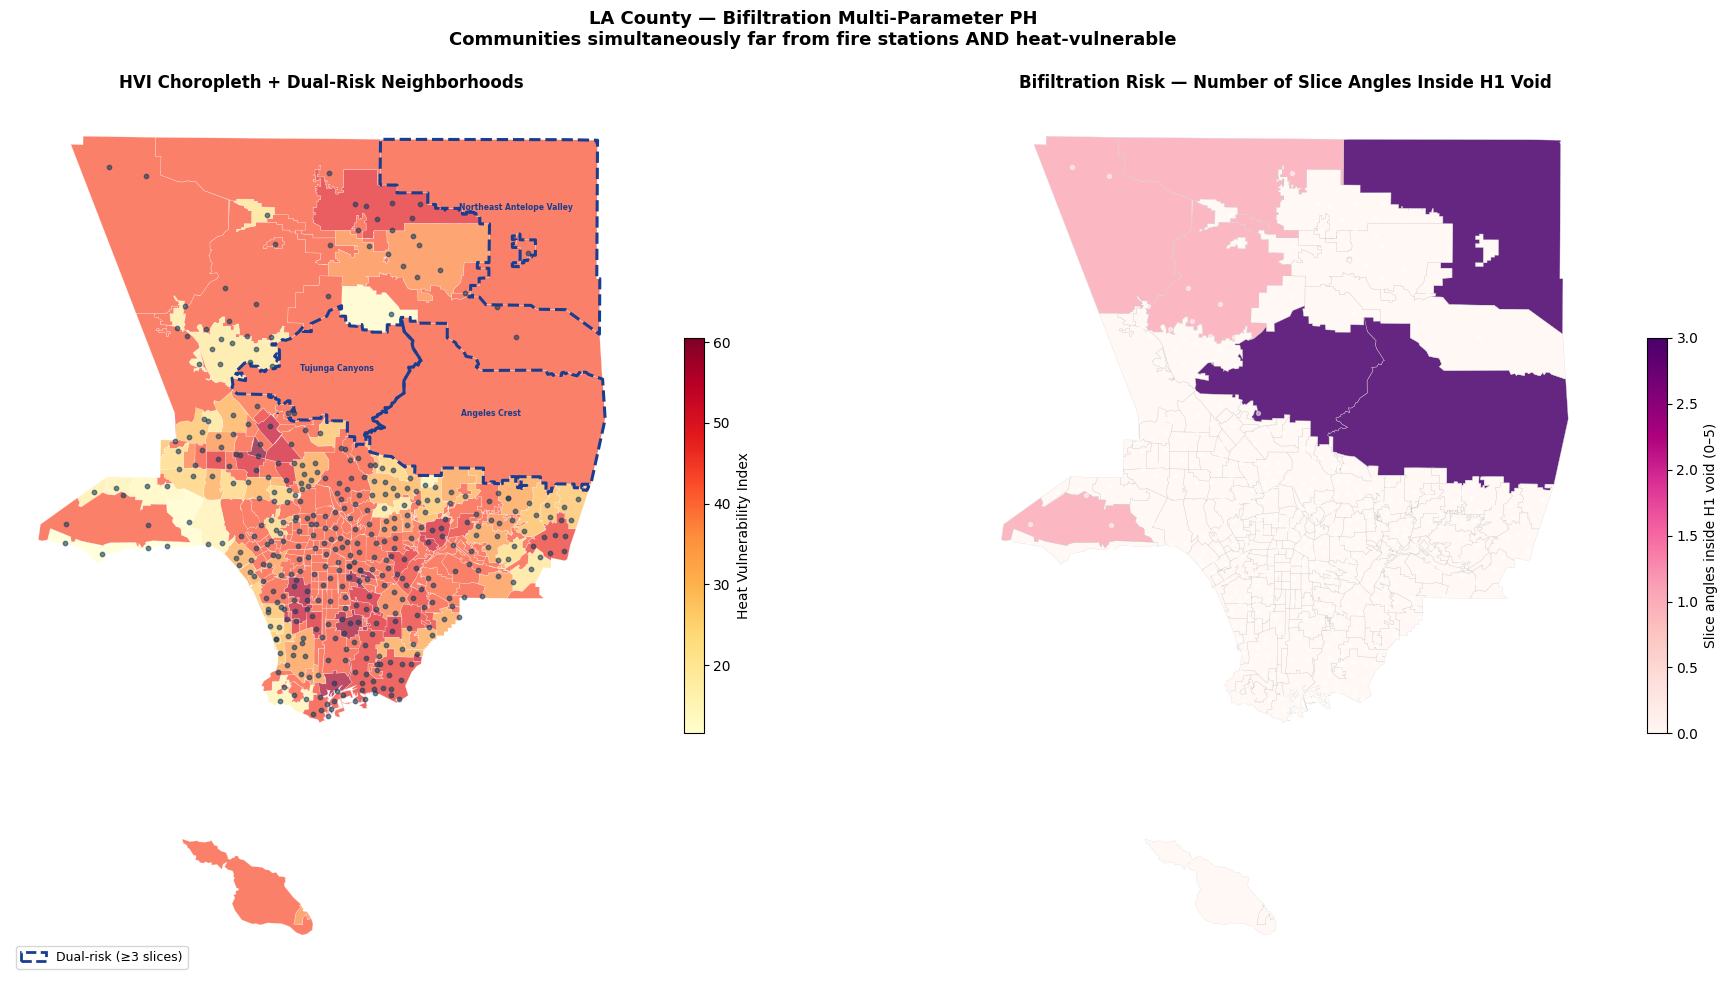

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# ── Left: HVI choropleth + dual-risk highlights ────────────────────────────
ax = axes[0]
county_proj.plot(
    column="hvi_median", ax=ax,
    cmap="YlOrRd", edgecolor="white", linewidth=0.25,
    alpha=0.70, legend=True,
    legend_kwds={"label": "Heat Vulnerability Index", "shrink": 0.45}
)

# Dual-risk neighborhoods — blue outline, bold
dual = county_proj[county_proj["dual_risk"]]
dual.plot(ax=ax, facecolor="none", edgecolor="#1a3d8f",
          linewidth=2.2, linestyle="--", zorder=5)

# Fire stations
ax.scatter(coords_stations[:,0], coords_stations[:,1],
           c="#1a3d5c", s=10, alpha=0.6, zorder=6, label="Fire station")

# Annotate top dual-risk neighborhoods
top_dual = county_proj[county_proj["dual_risk"]].nlargest(10, "n_slices_in_void")
for _, row in top_dual.iterrows():
    ax.annotate(
        row.get("name", ""),
        xy=(row["cx"], row["cy"]),
        fontsize=5.5, color="#1a3d8f",
        ha="center", va="bottom",
        fontweight="bold"
    )

dual_patch = mpatches.Patch(facecolor="none", edgecolor="#1a3d8f",
                             linewidth=2, linestyle="--",
                             label=f"Dual-risk (≥{DUAL_RISK_MIN_SLICES} slices)")
ax.legend(handles=[dual_patch], loc="lower left", fontsize=9)
ax.set_title("HVI Choropleth + Dual-Risk Neighborhoods",
             fontsize=12, fontweight="bold")
ax.set_axis_off()

# ── Right: number of slices in void ───────────────────────────────────────
ax2 = axes[1]
county_proj.plot(
    column="n_slices_in_void", ax=ax2,
    cmap="RdPu", edgecolor="white", linewidth=0.25,
    alpha=0.85, legend=True,
    legend_kwds={"label": "Slice angles inside H1 void (0–5)",
                 "shrink": 0.45}
)
county_proj.boundary.plot(ax=ax2, color="gray", linewidth=0.15, alpha=0.4)
ax2.scatter(coords_stations[:,0], coords_stations[:,1],
            c="white", s=8, alpha=0.5, zorder=5)
ax2.set_title("Bifiltration Risk — Number of Slice Angles Inside H1 Void",
              fontsize=12, fontweight="bold")
ax2.set_axis_off()

plt.suptitle(
    "LA County — Bifiltration Multi-Parameter PH\n"
    "Communities simultaneously far from fire stations AND heat-vulnerable",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
# plt.savefig("bifiltration_risk_map.png", dpi=150, bbox_inches="tight")
plt.show()
# print("Saved: bifiltration_risk_map.png")